<a href="https://colab.research.google.com/github/amherrera128/Analisis_de_datos/blob/FUNDAMENTOS-DE-INFORMACI%C3%93N-Y-TECNOLOG%C3%8DA-CU%C3%81NTICA/Eigensolver_Cu%C3%A1ntico_Variacional_(VQE)_Curso_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install qiskit qiskit-aer matplotlib pylatexenc 'qiskit[visualization]' qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.4 MB/s eta 0:00:00
  Created 

## Cálculo del valor propio mínimo de un Hamiltoniano simple

Empezaremos aplicando el VQE a un caso muy sencillo, para ver cómo funciona. Calcularemos el valor propio mínimo de la matriz de Pauli $Z$ con VQE. Empezaremos importando algunos paquetes generales.

In [ ]:
import numpy as np
from qiskit.circuit import ParameterVector, QuantumCircuit
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize

Ahora definimos el operador de interés y lo vemos en forma de matriz.



In [ ]:
op = SparsePauliOp("Z")
op.to_matrix()

array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

Es fácil obtener los valores propios clásicamente, por lo que podemos comprobar nuestro trabajo. Esto podría resultar difícil a medida que avanzamos hacia la utilidad. Aquí usamos numpy.



In [ ]:
# compute eigenvalues with numpy
result = np.linalg.eigh(op.to_matrix())
print("Eigenvalues:", result.eigenvalues)

Eigenvalues: [-1.  1.]


Para obtener los valores propios mediante un algoritmo cuántico variacional, construimos un circuito con puertas que toman parámetros variacionales:



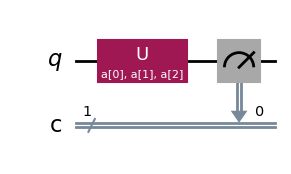

In [ ]:
# define a variational form
param = ParameterVector("a", 3)
qc = QuantumCircuit(1, 1)
qc.u(param[0], param[1], param[2], 0)
qc_estimator = qc.copy()
qc.measure(0, 0)
qc.draw("mpl")

Si queremos estimar el valor de la expectativa de un operador (como $Z$ ), debemos utilizar Estimator. Si queremos ver los estados del sistema, utilizamos Sampler.



In [ ]:
sampler = StatevectorSampler() #Probabilidades o conteos de resultados de medición
estimator = StatevectorEstimator() #Valores esperados de operadores

Podemos calcular recuentos de cadenas de bits 0 y 1 con valores de parámetros aleatorios `[1, 2, 3]` utilizando Sampler.



In [ ]:
# compute counts of bitstrings with random parameter values by Sampler
result = sampler.run([(qc, [1, 2, 3])]).result()
counts = result[0].data.c.get_counts()
counts

{'0': 780, '1': 244}

Sabemos que podemos calcular el valor de la expectativa de Z mediante $\langle Z \rangle = p_0 - p_1$ con las probabilidades $\{0: p_0, 1: p_1\}$.



In [ ]:
# compute the expectation value of Z based on the counts
(counts.get("0", 0) - counts.get("1", 0)) / sum(counts.values())

0.5234375

Este circuito funcionaba, pero los valores de los parámetros elegidos no correspondían a un estado de muy baja energía (o de bajo valor propio). El valor propio obtenido es bastante superior al mínimo. El resultado es similar cuando se utiliza el estimador.

Nótese que el Estimador toma circuitos cuánticos sin mediciones.



In [ ]:
result = estimator.run([(qc_estimator, op, [1, 2, 3])]).result()
result[0].data.evs

array(0.54030231)

Tendremos que buscar entre los parámetros y encontrar los que arrojen el valor propio más bajo.
Hacemos una función para recibir los valores de los parámetros de la forma variacional y devolver el valor esperado $\langle Z \rangle$.



In [ ]:
# define a cost function to look for the minimum eigenvalue of Z
def cost(x):
    result = sampler.run([(qc, x)]).result()
    counts = result[0].data.c.get_counts()
    expval = (counts.get("0", 0) - counts.get("1", 0)) / sum(counts.values())
    # the following line shows the trajectory of the optimization
    print(expval, counts)
    return expval

Apliquemos la función SciPy's `minimize` para encontrar el valor propio mínimo de Z.



In [ ]:
# minimize the cost function with scipy's minimize
min_result = minimize(cost, [0, 0, 0], method="COBYLA", tol=1e-8)
min_result

1.0 {'0': 1024}
0.576171875 {'0': 807, '1': 217}
0.5234375 {'0': 780, '1': 244}
0.580078125 {'0': 809, '1': 215}
-0.392578125 {'0': 311, '1': 713}
-0.662109375 {'0': 173, '1': 851}
-0.60546875 {'0': 202, '1': 822}
0.255859375 {'0': 643, '1': 381}
-0.66015625 {'0': 174, '1': 850}
-0.9921875 {'1': 1020, '0': 4}
-0.41796875 {'1': 726, '0': 298}
-0.99609375 {'1': 1022, '0': 2}
-0.9921875 {'1': 1020, '0': 4}
-0.998046875 {'1': 1023, '0': 1}
-0.951171875 {'1': 999, '0': 25}
-0.99609375 {'1': 1022, '0': 2}
-1.0 {'1': 1024}
-0.99609375 {'1': 1022, '0': 2}
-0.99609375 {'1': 1022, '0': 2}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-0.99609375 {'1': 1022, '0': 2}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-0.99609375 {'1': 1022, '0': 2}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}
-1.0 {'1': 1024}


 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.0
       x: [ 3.174e+00  5.049e-01  3.734e-01]
    nfev: 35
   maxcv: 0.0

In [ ]:
# check counts of bitstrings with the optimal parameters
result = sampler.run([(qc, min_result.x)]).result()
result[0].data.c.get_counts()

{'1': 1024}

<span id="21-exercise" />

### Ejercicio

Calcule el valor propio mínimo de $Z \otimes Z$ con VQE.



In [ ]:
z2 = SparsePauliOp("ZZ")
print(z2)
print(z2.to_matrix())

SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]


In [ ]:
# compute eigenvalues with numpy

In [ ]:
# define a variational form
# qc = ...

In [ ]:
# compute counts of bitstrings with a random parameter values by Sampler
# result = sampler.run(...)
# result

In [ ]:
# compute the expectation value of ZZ based on the counts

In [ ]:
# verify the expectation value of ZZ with Estimator

In [ ]:
# define a cost function to look for the minimum eigenvalue of ZZ
# def cost(x):
#    expval = ...
#    return expval

In [ ]:
# minimize the cost function with scipy's minimize
# min_result = minimize(cost, [...], method="COBYLA", tol=1e-8)
# min_result

In [ ]:
# check counts of bitstrings with the optimal parameter values
# result = sampler.run(qc, min_result.x).result()
# result